# Grad-CAM Visualization & Predictions — NIH ChestX-Ray14

**Project:** Multi-Label Thoracic Disease Classification using Deep Learning

---

## Notebook Objectives

1. Load the best trained model and test results from `03_training.ipynb`
2. Display 20 random test predictions with color-coded correctness
3. Generate Grad-CAM++ heatmaps showing which X-ray regions influenced the model's decision
4. Display a formatted comparison table across all trained models

> **Requires:** `data_essentials.pth` from `02_preprocessing.ipynb` and `best_{ModelName}_model.pth` from `03_training.ipynb`

## 1. Imports & Device Setup

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import device, cuda, load, nn
from torchvision.models import swin_v2_s, Swin_V2_S_Weights
import torchvision.transforms as transforms
from torch.utils.data import Dataset
from PIL import Image
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from warnings import filterwarnings
filterwarnings("ignore")

%matplotlib inline

dev = device("cuda" if cuda.is_available() else "cpu")
dev

device(type='cuda')

## 2. Load Data & Model Results

In [ ]:
checkpoint = load(r"data_essentials.pth", map_location=dev, weights_only=False)

IMG_FOLDERS    = checkpoint["img_folders"]
NUM_OF_CLASSES = checkpoint["num_of_classes"]
ALL_DISEASES   = checkpoint["all_diseases"]
test_df        = checkpoint["test_df"]

MEAN_NORM = [0.485, 0.456, 0.406]
STD_NORM  = [0.229, 0.224, 0.225]

print(f"Loaded {NUM_OF_CLASSES} classes: {ALL_DISEASES}")

Loaded 14 classes: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


In [ ]:
# Change this path to match the model you want to visualize
results = load(
    r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\My Reserch Papers\chest-xray-multilabel-classification\saved_models\best_SwinTransformer_model.pth",
    map_location=dev, weights_only=False
)

# Strip 'module.' prefix added by DataParallel during training
weights       = results['model_state']
weights_clean = {k.replace("module.", ""): v for k, v in weights.items()}

# test_preds  : binary (0/1) — used for metrics and prediction display
# test_probs  : float probabilities from sigmoid — used for Grad-CAM
# test_labels : ground truth
test_preds  = results["test_preds"]
test_probs  = results["test_probs"]
test_labels = results["test_labels"]

print(f"Test preds shape : {test_preds.shape}")
print(f"Test labels shape: {test_labels.shape}")

Test preds shape : (25596, 14)
Test labels shape: (25596, 14)


## 3. Helper Functions

In [ ]:
def denormalize(tensor):
    """Reverse ImageNet normalization for display. Returns values clamped to [0, 1]."""
    mean = torch.tensor(MEAN_NORM).view(3, 1, 1)
    std  = torch.tensor(STD_NORM).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)


def get_disease_names(label_vector):
    """Convert binary vector to disease name string. Returns 'No Finding' if all zeros."""
    diseases = [ALL_DISEASES[i] for i, v in enumerate(label_vector) if v == 1]
    return ", ".join(diseases) if diseases else "No Finding"


def get_title_color(true_vec, pred_vec):
    """Return green for perfect match, orange for partial, red for completely wrong."""
    true_set = set(np.where(true_vec == 1)[0])
    pred_set = set(np.where(pred_vec == 1)[0])
    if true_set == pred_set:
        return "green"
    elif len(true_set & pred_set) > 0:
        return "orange"
    else:
        return "red"

## 4. Load Test Images

We load 500 test images for visualization. Transform matches training (256×256 for Swin).
Change size to 224 for ResNet/VGG/ViT, or 299 for Inception.

In [ ]:
class ChestXRayDataset(Dataset):
    """Minimal dataset for visualization — loads images only, no labels."""

    def __init__(self, df, img_folders, transform=None):
        self.df          = df.reset_index(drop=True)
        self.img_folders = img_folders
        self.transform   = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, "Image Index"]
        for folder in self.img_folders:
            path = os.path.join(folder, img_name)
            if os.path.exists(path):
                img = Image.open(path).convert("RGB")
                break
        if self.transform:
            img = self.transform(img)
        return img


test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN_NORM, std=STD_NORM),
])

viz_dataset = ChestXRayDataset(
    test_df.iloc[:500].reset_index(drop=True),
    IMG_FOLDERS,
    transform=test_transform
)

all_imgs = [viz_dataset[i] for i in range(len(viz_dataset))]
print(f"Loaded {len(all_imgs)} images for visualization")

Loaded 500 images for visualization


## 5. Test Predictions — 20 Random Samples

🟢 Green = perfect | 🟠 Orange = partial match | 🔴 Red = completely wrong

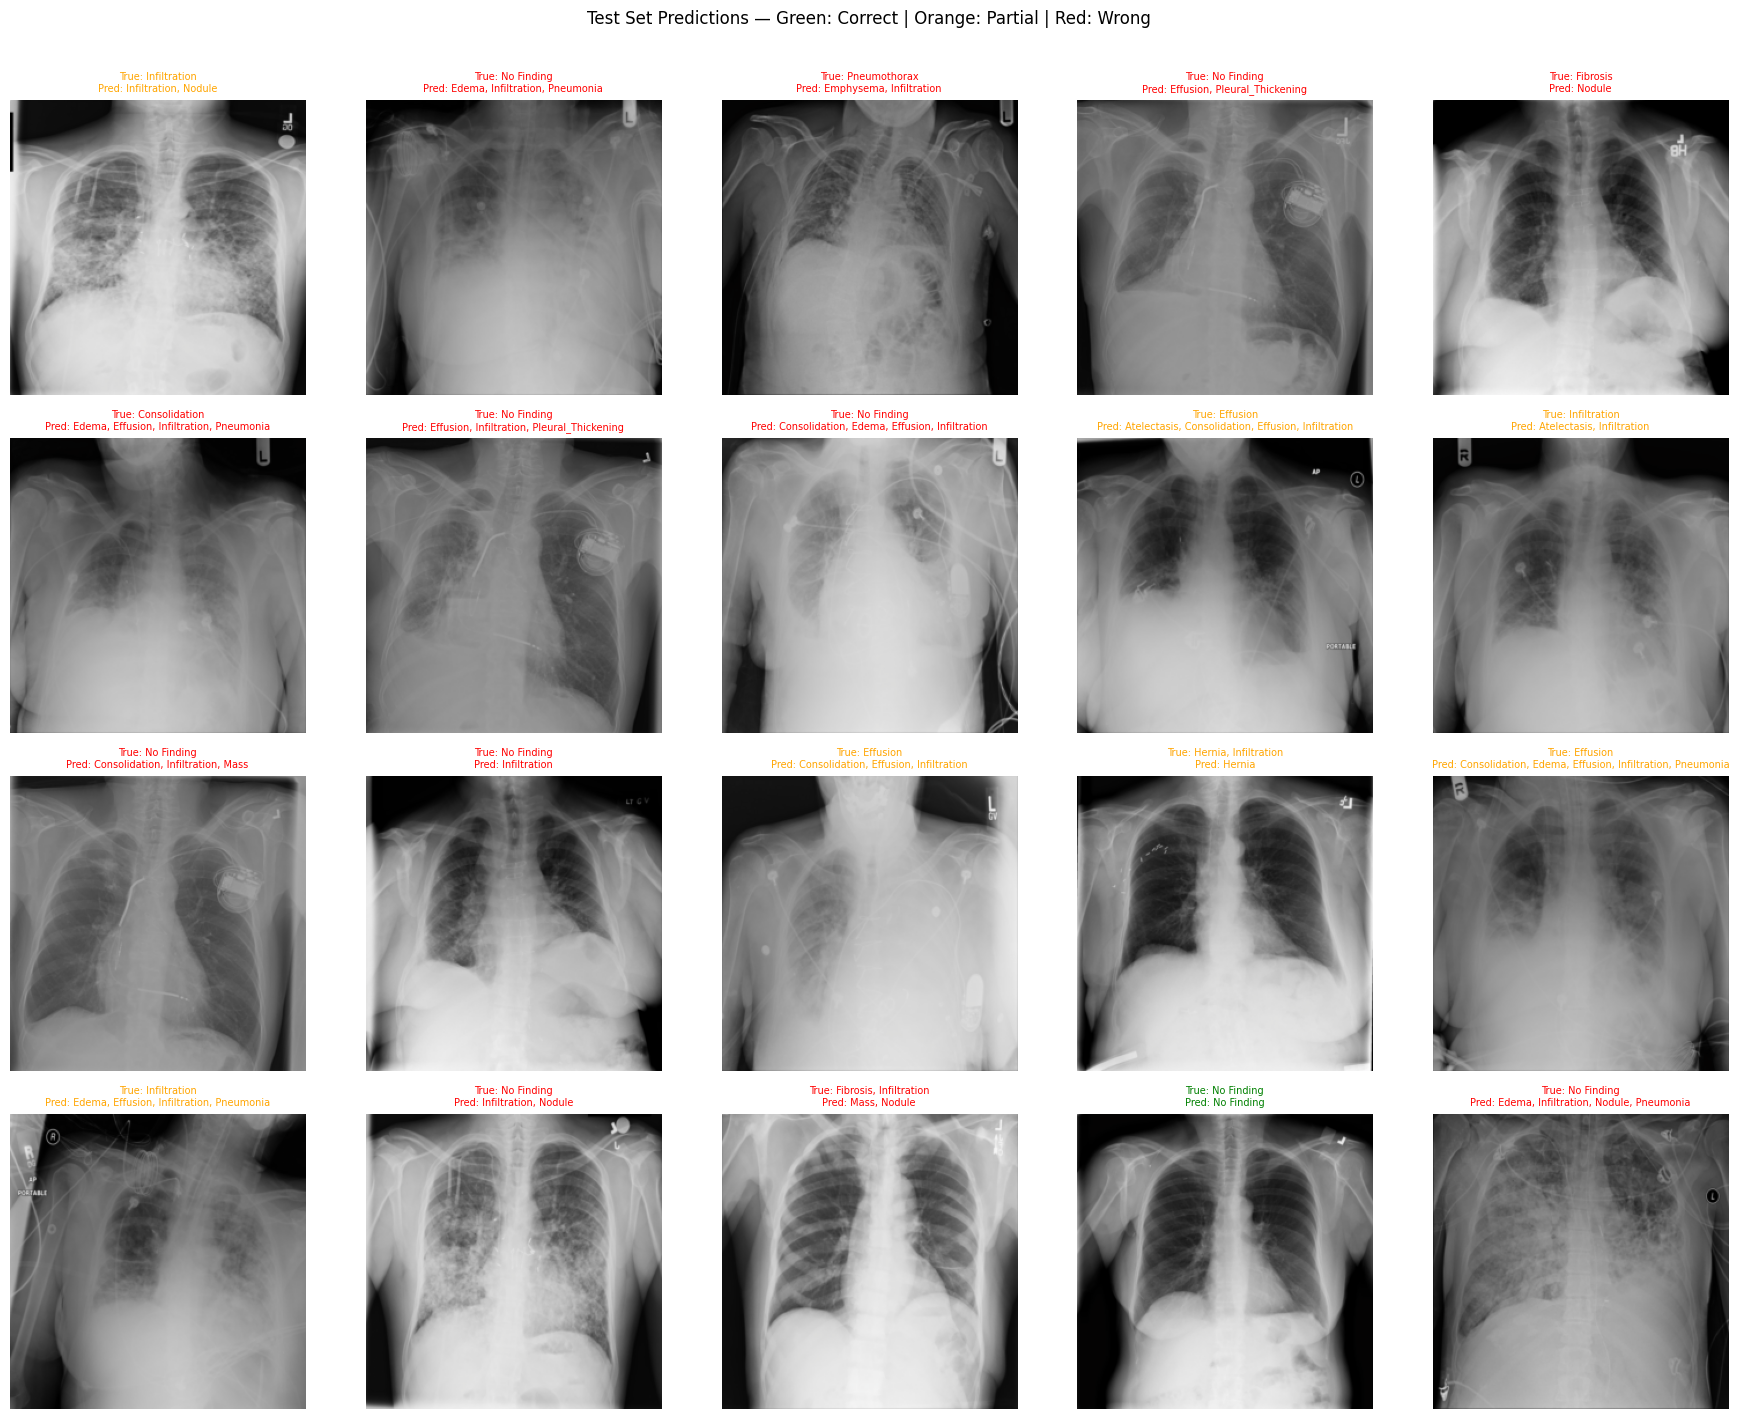

In [ ]:
_, ax = plt.subplots(4, 5, figsize=(18, 14))
ax = ax.flatten()

max_idx = min(len(all_imgs), len(test_labels))
indices = np.random.choice(max_idx, size=20, replace=False)

for plot_i, idx in enumerate(indices):
    img        = denormalize(all_imgs[idx]).permute(1, 2, 0).numpy()
    true_label = get_disease_names(test_labels[idx])
    pred_label = get_disease_names(test_preds[idx])
    color      = get_title_color(test_labels[idx], test_preds[idx])

    ax[plot_i].imshow(img, cmap="gray")
    ax[plot_i].set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=7)
    ax[plot_i].axis("off")

plt.suptitle("Test Set Predictions — Green: Correct | Orange: Partial | Red: Wrong",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 6. Grad-CAM++ Heatmaps

Grad-CAM++ highlights the X-ray regions that most influenced the model's prediction.
Red/warm areas = high attention from the model.

**Why GradCAM++ over standard GradCAM?**  
GradCAM++ uses higher-order gradients which gives more precise localization,
especially useful for multi-label cases where multiple diseases appear in one image.

**Why a custom MultiLabelTarget?**  
Standard Grad-CAM targets a single class. Here we sum scores of all predicted
positive diseases to produce a combined heatmap covering all relevant regions.

**reshape_transform for Swin:**  
Swin outputs features as `(batch, H*W, channels)`. The reshape converts this
to `(batch, channels, H, W)` as expected by Grad-CAM.

In [ ]:
def build_model(model_fn, model_weights):
    """Build model with the same classifier structure used during training."""
    model = model_fn(model_weights.DEFAULT)
    model.head = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(model.head.in_features, NUM_OF_CLASSES)
    )
    return model.to(dev).eval()


model = build_model(swin_v2_s, Swin_V2_S_Weights)
model.load_state_dict(weights_clean)
model.eval()
print("Model loaded successfully")

Model loaded successfully


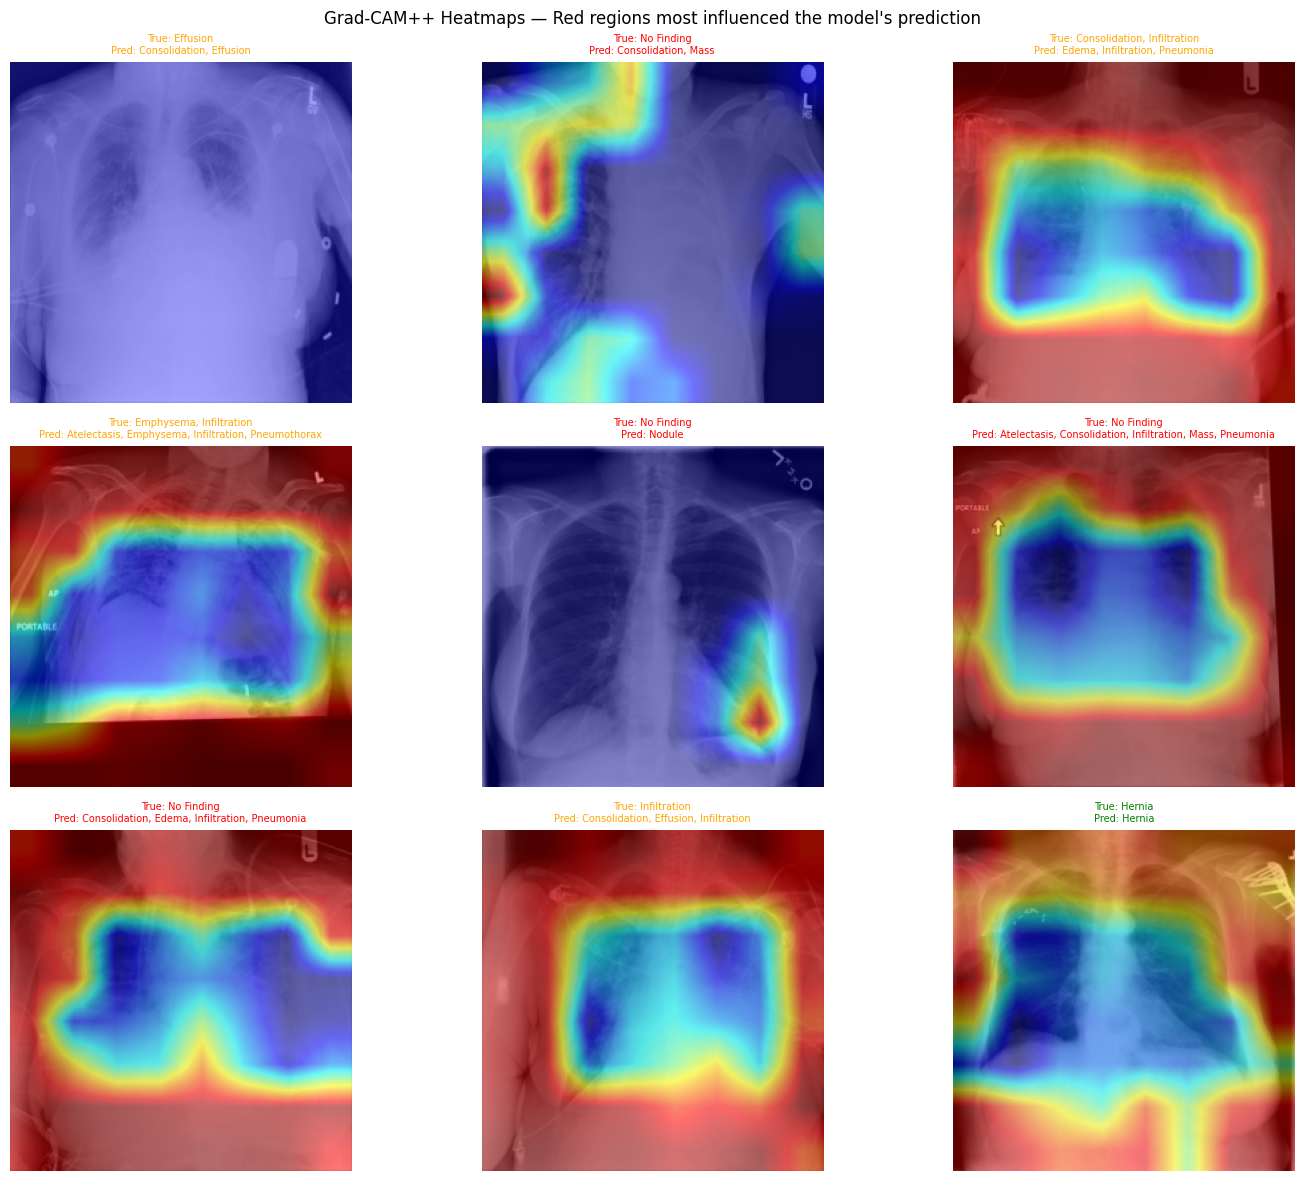

In [ ]:
class MultiLabelTarget:
    """Sums scores of all predicted positive diseases for a combined Grad-CAM heatmap."""

    def __init__(self, pred_vector):
        self.pred_vector = torch.tensor(pred_vector, dtype=torch.float32)

    def __call__(self, model_output):
        return (model_output * self.pred_vector.to(model_output.device)).sum()


def show_gradcam(model, img_tensor, pred_vector, true_label, pred_label, ax):
    """Generate and display a Grad-CAM++ heatmap overlay for a single image."""

    # Target the last normalization layer of the final Swin stage
    target_layers = [model.features[-1][-1].norm1]

    # Swin outputs (batch, H*W, C) — reshape to (batch, C, H, W) for Grad-CAM
    cam = GradCAMPlusPlus(
        model=model,
        target_layers=target_layers,
        reshape_transform=lambda x: x.permute(0, 3, 1, 2)
    )

    input_tensor  = img_tensor.unsqueeze(0).to(dev)
    grayscale_cam = cam(input_tensor=input_tensor, targets=[MultiLabelTarget(pred_vector)])

    img_np        = denormalize(img_tensor).permute(1, 2, 0).numpy()
    visualization = show_cam_on_image(img_np, grayscale_cam[0], use_rgb=True)

    color = get_title_color(
        np.array([1 if d in true_label else 0 for d in ALL_DISEASES]),
        pred_vector
    )

    ax.imshow(visualization)
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=7)
    ax.axis("off")


# Select images that have at least one predicted disease (more informative heatmaps)
has_pred = [i for i in range(min(len(all_imgs), len(test_preds)))
            if test_preds[i].sum() > 0]

selected = np.random.choice(has_pred, size=min(9, len(has_pred)), replace=False)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for plot_i, idx in enumerate(selected):
    show_gradcam(
        model       = model,
        img_tensor  = all_imgs[idx],
        pred_vector = test_preds[idx],
        true_label  = get_disease_names(test_labels[idx]),
        pred_label  = get_disease_names(test_preds[idx]),
        ax          = axes[plot_i]
    )

plt.suptitle("Grad-CAM++ Heatmaps — Red regions most influenced the model's prediction",
             fontsize=12)
plt.tight_layout()
plt.show()

## 7. Model Comparison Table

Loads the results CSV saved during training and displays a formatted comparison
across all five models. Best values highlighted in green.

In [ ]:
results_path = r'C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\My Reserch Papers\chest-xray-multilabel-classification\results\All_Models_Results.csv'

results_df = pd.read_csv(results_path)

# Sort by AUC descending — Swin (proposed) should rank first
results_df = results_df.sort_values('AUC', ascending=False).reset_index(drop=True)

# Highlight best AUC, F1, Recall in green and fastest training in yellow
styled = results_df.style \
    .highlight_max(subset=['AUC', 'F1', 'Recall'], color='lightgreen') \
    .highlight_min(subset=['Training_Time (Hours)'], color='lightyellow') \
    .format({
        'AUC': '{:.4f}', 'F1': '{:.4f}',
        'Precision': '{:.4f}', 'Recall': '{:.4f}',
        'Training_Time (Hours)': '{:.2f}'
    })

display(styled)

,Model,AUC,F1,Precision,Recall,Training_Time (Hours)
0,SwinTransformer,0.8368,0.3859,0.2766,0.5237,5.31
1,Inception3,0.8366,0.3198,0.2522,0.4833,4.32
2,ResNet,0.8270,0.3128,0.2454,0.4858,2.95
3,VisionTransformer,0.8071,0.2791,0.2241,0.4150,5.52
4,VGG,0.7897,0.2459,0.1807,0.4509,8.56
